In [ ]:
"""
Lab 1 -- Linear Regression

Deep Learning
Esraaj Sarkar Gupta,

30th August, 2026
"""

In [7]:
# ---- Imports ---- #
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn

from pathlib import Path
import matplotlib.pyplot as plt

In [12]:
# ---- Load Data ---- #
data_path: Path = Path("data/auto-mpg.data")

# I picked these by hand
col_names = [
    'mpg',
    'cylinders',
    'displacement',
    'horsepower',
    'weight',
    'acceleration',
    'model_year',
    'origin',
    'car_name',
]

df = pd.read_csv(data_path, names=col_names, na_values="?", sep=r'\s+')
df = df.dropna().drop(columns=['car_name'])  # Clean it up
# Extract a matrix of all the independent features
X_raw = df.drop(columns = ["mpg"]).values
# Extract the dependent feature
Y_raw = df["mpg"].values.reshape(-1, 1)

# Z-score normalization of dependent features
X_mean = np.mean(X_raw, axis = 0)
X_std = np.std(X_raw, axis = 0)
X_scaled = (X_raw - X_mean) / X_std

X_aug = torch.tensor(
    np.hstack([torch.ones((X_scaled.shape[0], 1)), X_scaled]),
    dtype=torch.float32
    )
Y_tensor = torch.tensor(Y_raw, dtype=torch.float32)

# Analytical Solution
w_analytical = torch.linalg.inv(X_aug.T @ X_aug) @ X_aug.T @ Y_tensor
print(f"Analytical Weights:\n{w_analytical.squeeze()}\n")


Analytical Weights:
tensor([23.4459, -0.8405,  2.0793, -0.6516, -5.4920,  0.2220,  2.7621,  1.1473])



In [13]:
# ---- Serious Numerical Mathematics Cell ---- #
# Comments must be very serious here, because we are doing serious things here!
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default') # I don't know what this line does.

def train_linear_model_with_history(X, Y, batch_size, lr=0.01, epochs=500):
    """The function that does it all!"""
    # Load the data into the function
    dataset = TensorDataset(X, Y)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    # Bring in the numerical optimization
    torch.manual_seed(24)   # I prefer the number 24 to 42. 
    w = torch.randn((X.shape[1], 1), requires_grad=True)
    optimizer = torch.optim.SGD([w], lr=lr)
    criterion = torch.nn.MSELoss()

    loss_history : list = list([]) # I specify this to be a list twice (so I don't forget, and neither do you)
    
    # Start looping
    for epoch in range(epochs):
        epoch_loss = 0.0    # Init
        
        for bx, by in loader:
            optimizer.zero_grad()
            predictions = bx @ w
            loss = criterion(predictions, by)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(bx)
        loss_history.append(epoch_loss / len(X))
            
    return w.detach(), loss_history

# Re-run training with history tracking
w_bgd, loss_bgd = train_linear_model_with_history(X_aug, Y_tensor, batch_size=len(X_aug), lr=0.05, epochs=1000)
w_mbgd, loss_mbgd = train_linear_model_with_history(X_aug, Y_tensor, batch_size=32, lr=0.01, epochs=500)
w_sgd, loss_sgd = train_linear_model_with_history(X_aug, Y_tensor, batch_size=1, lr=0.001, epochs=200)

feature_labels = ['Bias', 'Cylinders', 'Displacement', 'Horsepower', 'Weight', 'Acceleration', 'Model Year', 'Origin']

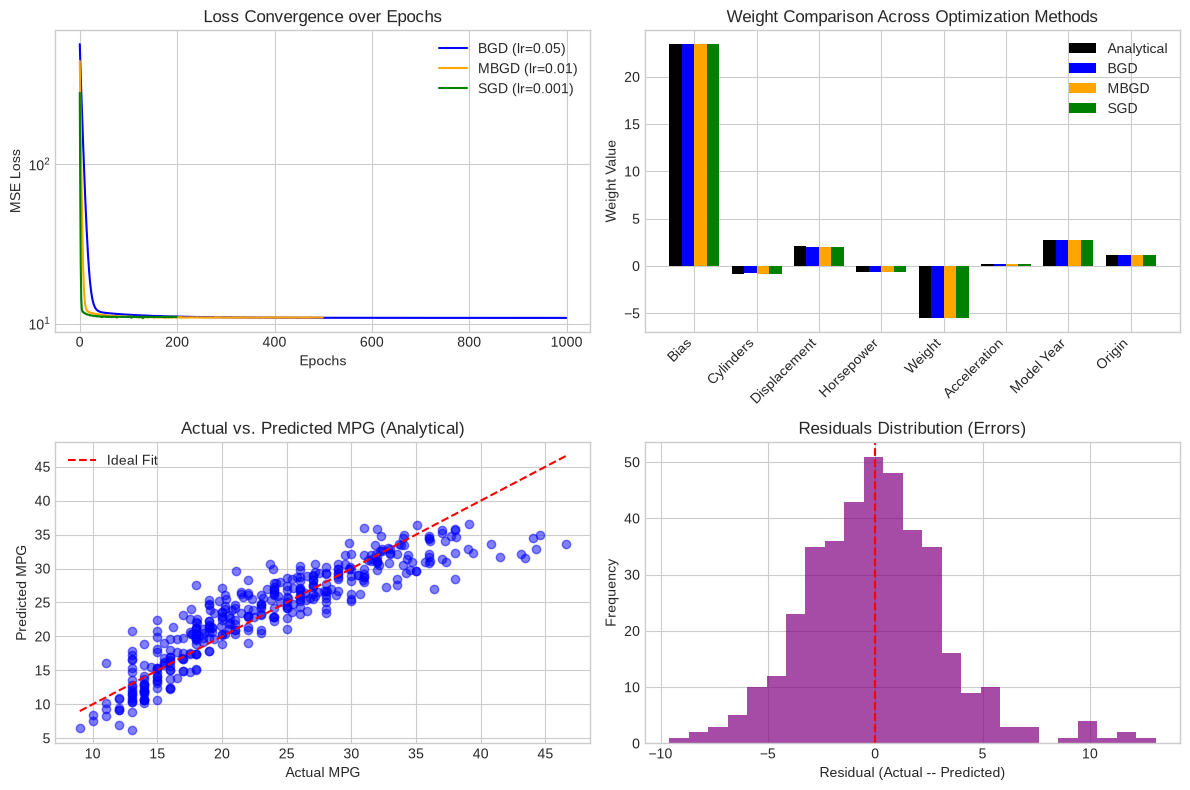

In [14]:
# ---- Make Me Look Pretty ---- #
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Loss Convergence Curves
# Impressive how well these actuallty converge.
axes[0, 0].plot(loss_bgd, label='BGD (lr=0.05)', color='blue')
axes[0, 0].plot(loss_mbgd, label='MBGD (lr=0.01)', color='orange')
axes[0, 0].plot(loss_sgd[:200], label='SGD (lr=0.001)', color='green')
axes[0, 0].set_title('Loss Convergence over Epochs')
axes[0, 0].set_xlabel('Epochs')
axes[0, 0].set_ylabel('MSE Loss')
axes[0, 0].set_yscale('log')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Weight Values Comparison
# Is anyone actually even reading these comments?
x_indices = np.arange(len(feature_labels))
width = 0.2

axes[0, 1].bar(x_indices - 1.5*width, w_analytical.squeeze().numpy(), width, label='Analytical', color='black')
axes[0, 1].bar(x_indices - 0.5*width, w_bgd.squeeze().numpy(), width, label='BGD', color='blue')
axes[0, 1].bar(x_indices + 0.5*width, w_mbgd.squeeze().numpy(), width, label='MBGD', color='orange')
axes[0, 1].bar(x_indices + 1.5*width, w_sgd.squeeze().numpy(), width, label='SGD', color='green')

axes[0, 1].set_title('Weight Comparison Across Optimization Methods')
axes[0, 1].set_xticks(x_indices)
axes[0, 1].set_xticklabels(feature_labels, rotation=45, ha='right')
axes[0, 1].set_ylabel('Weight Value')
axes[0, 1].legend()

# Pairity Plot -- Using Analytical Weight
y_pred = (X_aug @ w_analytical).numpy()
y_true = Y_tensor.numpy()

axes[1, 0].scatter(y_true, y_pred, color='blue', alpha=0.5)
axes[1, 0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', label='Ideal Fit')
axes[1, 0].set_title('Actual vs. Predicted MPG (Analytical)')
axes[1, 0].set_xlabel('Actual MPG')
axes[1, 0].set_ylabel('Predicted MPG')
axes[1, 0].legend()

# Residual Distribution Fiugure
residuals = y_true - y_pred
axes[1, 1].hist(residuals, bins=25, color='purple', alpha=0.7) # It's a very nice colour!
axes[1, 1].axvline(0, color='red', linestyle='--')
axes[1, 1].set_title('Residuals Distribution (Errors)')
axes[1, 1].set_xlabel('Residual (Actual -- Predicted)')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()